# MiniRocket — BCI Competition IV 2a

Experimentos completos:
1. **LOSO** sobre datos combinados T+E — 2 clases
2. **LOSO** sobre datos combinados T+E — 4 clases
3. **Ablación de canales** (11ch vs 22ch) con la mejor config por clase
4. **Within-subject T→E** (estándar competición) con la mejor config por clase

Flujo:
- LOSO usa T+E combinados (~576 trials/sujeto) → generalización entre sujetos.
- Within-subject usa T para entrenar y E para evaluar → comparable con literatura.
- MiniRocket extrae ~10 000 features PPV con kernels dilatados (casi deterministas).
- El clasificador es Ridge con validación cruzada interna para seleccionar alpha.
- **No hay backprop, no hay GPU necesaria**: el transform es cerrado y lineal.

## 0 · Imports

In [1]:
import sys
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = os.path.abspath('..')
sys.path.append(PROJECT_ROOT)

from src.load_data_BCICIV import load_all_subjects, load_combined
from src.train_MiniRocket import run_loso, run_within_subject_T_to_E
from src.preprocess import laplacian_filter, apply_ea_loso, apply_ea_loso_multiband, euclidean_alignment

np.random.seed(42)
random.seed(42)

/home/alumno/Desktop/datos/a/Biosignal-ML-Analysis/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Configuración de rutas

In [2]:
DATA_DIR  = '../datasets/BCICIV_2a_gdf'
LABEL_DIR = '../datasets/BCICIV_2a_gdf/true_labels'

## 2 · Diferencias clave respecto a CSP y EEGNet

| Aspecto | CSP | EEGNet | **MiniRocket** |
|---|---|---|---|
| Transform | CSP (sklearn) | Convoluciones aprendidas | PPV kernels fijos (sktime) |
| Clasificador | LDA / SVM | Softmax (PyTorch) | **RidgeCV** |
| Entrenamiento | sklearn fit | backprop + GPU | Solve lineal (CPU) |
| Hiperparámetros principales | n_components, reg | lr, epochs | num_kernels, alpha |
| Formato de entrada | (trials, ch, time) | (trials, ch, time) | **(trials, ch, time)** ✓ |
| Velocidad | Rápido | Lento | **Muy rápido** |

**El formato de entrada es idéntico**, por lo que `load_combined` y `load_all_subjects`
se usan exactamente igual que en los otros notebooks.

## 3 · Grid de experimentos

In [3]:
EXPERIMENT_GRID = [
    {'name': 'base',          'use_multiband': False, 'use_laplacian': False},
    {'name': 'multiband',     'use_multiband': True,  'use_laplacian': False},
    {'name': 'laplacian',     'use_multiband': False, 'use_laplacian': True},
    {'name': 'multiband_lap', 'use_multiband': True,  'use_laplacian': True},
]

for cfg in EXPERIMENT_GRID:
    cfg['num_kernels'] = 10_000
    cfg['alphas'] = np.logspace(-3, 3, 10)

print(f'{len(EXPERIMENT_GRID)} configs × 2 clases = {len(EXPERIMENT_GRID)*2} runs LOSO')

4 configs × 2 clases = 8 runs LOSO


## 4 · Carga de datos combinados T+E (para LOSO)

In [4]:
print('Loading 11ch data (base + multiband) for 2 and 4 classes...')

X2,    y2,    subj2    = load_combined(DATA_DIR, LABEL_DIR, n_classes=2)
X4,    y4,    subj4    = load_combined(DATA_DIR, LABEL_DIR, n_classes=4)

X2_mb, y2_mb, subj2_mb = load_combined(DATA_DIR, LABEL_DIR, n_classes=2, use_multiband=True)
X4_mb, y4_mb, subj4_mb = load_combined(DATA_DIR, LABEL_DIR, n_classes=4, use_multiband=True)

print(f'Base  2cls: {X2.shape}    | multiband 2cls: {X2_mb.shape}')
print(f'Base  4cls: {X4.shape}    | multiband 4cls: {X4_mb.shape}')

Loading 11ch data (base + multiband) for 2 and 4 classes...


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A01T.gdf | left_hand: 71 | right_hand: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A02T.gdf | left_hand: 72 | right_hand: 72


...

Loading (eval multiband): A07E.gdf | Shape: (287, 2, 11, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval multiband): A08E.gdf | Shape: (287, 2, 11, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval multiband): A09E.gdf | Shape: (287, 2, 11, 1000)
Combined T+E | Shape: (5166, 2, 11, 1000) | ~574 trials/subject
Base  2cls: (2589, 11, 1000)    | multiband 2cls: (2589, 2, 11, 1000)
Base  4cls: (5166, 11, 1000)    | multiband 4cls: (5166, 2, 11, 1000)


## 5 · Helper: preparar X según config

MiniRocket acepta `(n_trials, n_channels, n_timepoints)`, exactamente igual que CSP.
El reshape para multiband es idéntico al del notebook CSP.

In [5]:
LAP_PARAMS = {
    11: {'ch': [3, 7],  'neigh': [[0, 2, 4, 9], [1, 6, 8, 10]]},
    22: {'ch': [7, 11], 'neigh': [[1, 6, 8, 13], [5, 10, 12, 17]]},
}

def prepare_X(cfg, X_base, X_mb, subjs_base, subjs_mb):
    if cfg['use_multiband']:
        X_mb = apply_ea_loso_multiband(X_mb, subjs_mb)
        trials, bands, channels, samples = X_mb.shape
        p = LAP_PARAMS[channels]

        if cfg['use_laplacian']:
            X_out = np.stack(
                [laplacian_filter(X_mb[:, b, :, :], p['ch'], p['neigh'])
                 for b in range(bands)],
                axis=1
            )
        else:
            X_out = X_mb

        return X_out.reshape(trials, bands * channels, samples)

    else:
        X_base = apply_ea_loso(X_base, subjs_base)
        trials, channels, samples = X_base.shape
        p = LAP_PARAMS[channels]

        if cfg['use_laplacian']:
            return laplacian_filter(X_base, p['ch'], p['neigh'])
        return X_base

## 6 · Experimentos LOSO — 2 clases

In [6]:
results_loso_2 = []

for cfg in EXPERIMENT_GRID:
    X_use = prepare_X(cfg, X2, X2_mb, subj2, subj2_mb)
    y_use = y2_mb if cfg['use_multiband'] else y2

    run_name = f"MiniRocket_2cls_{cfg['name']}"
    print(f'\n=== LOSO 2cls | {run_name} ===')
    print(f'    X shape: {X_use.shape}  |  num_kernels: {cfg["num_kernels"]}')

    res = run_loso(X_use, y_use, subj2, cfg, num_classes=2, run_name=run_name)

    results_loso_2.append({
        'config':   cfg['name'],
        'classes':  2,
        'mean_acc': res['mean'],
        'std_acc':  res['std'],
        **res['per_subject'],
    })

df_loso_2 = pd.DataFrame(results_loso_2).sort_values('mean_acc', ascending=False)
print('\n--- Results LOSO 2 classes ---')
df_loso_2[['config', 'mean_acc', 'std_acc']]


=== LOSO 2cls | MiniRocket_2cls_base ===
    X shape: (2589, 11, 1000)  |  num_kernels: 10000
  subject A01 → acc=0.6028
  subject A02 → acc=0.5417
  subject A03 → acc=0.6354
  subject A04 → acc=0.5280
  subject A05 → acc=0.6111
  subject A06 → acc=0.5278
  subject A07 → acc=0.6632
  subject A08 → acc=0.5660
  subject A09 → acc=0.5312

[MiniRocket_2cls_base]  mean=0.5786 ± 0.0482

=== LOSO 2cls | MiniRocket_2cls_multiband ===
    X shape: (2589, 22, 1000)  |  num_kernels: 10000
  subject A01 → acc=0.6585
  subject A02 → acc=0.5799
  subject A03 → acc=0.5590
  subject A04 → acc=0.5385
  subject A05 → acc=0.6215
  subject A06 → acc=0.5625
  subject A07 → acc=0.6840
  subject A08 → acc=0.5243
  subject A09 → acc=0.4861

[MiniRocket_2cls_multiband]  mean=0.5794 ± 0.0606

=== LOSO 2cls | MiniRocket_2cls_laplacian ===
    X shape: (2589, 11, 1000)  |  num_kernels: 10000
  subject A01 → acc=0.6132
  subject A02 → acc=0.5590
  subject A03 → acc=0.6979
  subject A04 → acc=0.5000
  subject A05 

,config,mean_acc,std_acc
2,laplacian,0.582413,0.063568
1,multiband,0.579373,0.060644
0,base,0.578572,0.048233
3,multiband_lap,0.565831,0.055016


## 7 · Experimentos LOSO — 4 clases

In [7]:
results_loso_4 = []

for cfg in EXPERIMENT_GRID:
    X_use = prepare_X(cfg, X4, X4_mb, subj4, subj4_mb)
    y_use = y4_mb if cfg['use_multiband'] else y4

    run_name = f"MiniRocket_4cls_{cfg['name']}"
    print(f'\n=== LOSO 4cls | {run_name} ===')
    print(f'    X shape: {X_use.shape}  |  num_kernels: {cfg["num_kernels"]}')

    res = run_loso(X_use, y_use, subj4, cfg, num_classes=4, run_name=run_name)

    results_loso_4.append({
        'config':   cfg['name'],
        'classes':  4,
        'mean_acc': res['mean'],
        'std_acc':  res['std'],
        **res['per_subject'],
    })

df_loso_4 = pd.DataFrame(results_loso_4).sort_values('mean_acc', ascending=False)
print('\n--- Results LOSO 4 classes ---')
df_loso_4[['config', 'mean_acc', 'std_acc']]


=== LOSO 4cls | MiniRocket_4cls_base ===
    X shape: (5166, 11, 1000)  |  num_kernels: 10000
  subject A01 → acc=0.4373
  subject A02 → acc=0.4251
  subject A03 → acc=0.3955
  subject A04 → acc=0.3014
  subject A05 → acc=0.3502
  subject A06 → acc=0.2962
  subject A07 → acc=0.3955
  subject A08 → acc=0.3502
  subject A09 → acc=0.3798

[MiniRocket_4cls_base]  mean=0.3701 ± 0.0470

=== LOSO 4cls | MiniRocket_4cls_multiband ===
    X shape: (5166, 22, 1000)  |  num_kernels: 10000
  subject A01 → acc=0.4443
  subject A02 → acc=0.3850
  subject A03 → acc=0.3902
  subject A04 → acc=0.3275
  subject A05 → acc=0.3571
  subject A06 → acc=0.3223
  subject A07 → acc=0.3972
  subject A08 → acc=0.3101
  subject A09 → acc=0.3833

[MiniRocket_4cls_multiband]  mean=0.3686 ± 0.0407

=== LOSO 4cls | MiniRocket_4cls_laplacian ===
    X shape: (5166, 11, 1000)  |  num_kernels: 10000
  subject A01 → acc=0.4338
  subject A02 → acc=0.4216
  subject A03 → acc=0.3676
  subject A04 → acc=0.2892
  subject A05 

,config,mean_acc,std_acc
3,multiband_lap,0.373597,0.044044
0,base,0.370112,0.047021
1,multiband,0.368564,0.040660
2,laplacian,0.357917,0.048015


## 8 · Resumen LOSO y selección del mejor modelo

In [8]:
df_all_loso = pd.concat([df_loso_2, df_loso_4], ignore_index=True)

print('===== Global ranking LOSO =====')
print(df_all_loso[['config', 'classes', 'mean_acc', 'std_acc']]
      .sort_values('mean_acc', ascending=False).to_string(index=False))

best_2cls = df_loso_2.iloc[0]
best_4cls = df_loso_4.iloc[0]

print(f'\nBest for 2 classes → {best_2cls["config"]}'
      f'  ({best_2cls["mean_acc"]:.4f} ± {best_2cls["std_acc"]:.4f})')
print(f'Best for 4 classes → {best_4cls["config"]}'
      f'  ({best_4cls["mean_acc"]:.4f} ± {best_4cls["std_acc"]:.4f})')

best_cfg_2 = next(c for c in EXPERIMENT_GRID if c['name'] == best_2cls['config'])
best_cfg_4 = next(c for c in EXPERIMENT_GRID if c['name'] == best_4cls['config'])

===== Global ranking LOSO =====
       config  classes  mean_acc  std_acc
    laplacian        2  0.582413 0.063568
    multiband        2  0.579373 0.060644
         base        2  0.578572 0.048233
multiband_lap        2  0.565831 0.055016
multiband_lap        4  0.373597 0.044044
         base        4  0.370112 0.047021
    multiband        4  0.368564 0.040660
    laplacian        4  0.357917 0.048015

Best for 2 classes → laplacian  (0.5824 ± 0.0636)
Best for 4 classes → multiband_lap  (0.3736 ± 0.0440)


## 9 · Ablación de canales — 11ch vs 22ch con la mejor config

In [9]:
print('Loading 22ch data for channel ablation...')

if best_cfg_2['use_multiband']:
    X2_22, y2_22, subj2_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=2, use_multiband=True, channels_to_use='all'
    )
else:
    X2_22, y2_22, subj2_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=2, channels_to_use='all'
    )

if best_cfg_4['use_multiband']:
    X4_22, y4_22, subj4_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=4, use_multiband=True, channels_to_use='all'
    )
else:
    X4_22, y4_22, subj4_22 = load_combined(
        DATA_DIR, LABEL_DIR, n_classes=4, channels_to_use='all'
    )

Loading 22ch data for channel ablation...


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A01T.gdf | left_hand: 71 | right_hand: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A02T.gdf | left_hand: 72 | right_hand: 72


...

Loading (eval multiband): A07E.gdf | Shape: (287, 2, 22, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval multiband): A08E.gdf | Shape: (287, 2, 22, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval multiband): A09E.gdf | Shape: (287, 2, 22, 1000)
Combined T+E | Shape: (5166, 2, 22, 1000) | ~574 trials/subject


In [11]:
results_ch_ablation = []

for n_cls, best_cfg, df_src, (X_11, y_11, s_11), (X_22, y_22, s_22), (X_11_mb, y_11_mb), (X_22_mb, y_22_mb) in [
    (2, best_cfg_2, df_loso_2,
     (X2,    y2,    subj2),    (X2_22, y2_22, subj2_22),
     (X2_mb, y2_mb),           (X2_22, y2_22)),
    (4, best_cfg_4, df_loso_4,
     (X4,    y4,    subj4),    (X4_22, y4_22, subj4_22),
     (X4_mb, y4_mb),           (X4_22, y4_22)),
]:
    for label, X_base, X_mb, y_base, subj in [
        ('11ch', X_11,  X_11_mb, y_11,  s_11),
        ('22ch', X_22,  X_22_mb, y_22,  s_22),
    ]:
        if label == '11ch':
            row = df_src[df_src['config'] == best_cfg['name']].iloc[0]
            results_ch_ablation.append({
                'channels': label, 'classes': n_cls,
                'config':   best_cfg['name'],
                'mean_acc': row['mean_acc'], 'std_acc': row['std_acc'],
            })
            print(f'  {n_cls}cls {label}: reusing LOSO → {row["mean_acc"]:.4f}')
            continue

        X_use = prepare_X(best_cfg, X_base, X_mb, subj, subj)
        y_use = y_22_mb if best_cfg['use_multiband'] else y_base

        run_name = f"MiniRocket_{n_cls}cls_{best_cfg['name']}_{label}"
        print(f'\n=== Ablation | {n_cls} cls | {best_cfg["name"]} | {label} ===')
        res = run_loso(X_use, y_use, subj, best_cfg, num_classes=n_cls, run_name=run_name)
        results_ch_ablation.append({
            'channels': label, 'classes': n_cls,
            'config':   best_cfg['name'],
            'mean_acc': res['mean'], 'std_acc': res['std'],
        })

df_ch_ablation = pd.DataFrame(results_ch_ablation)
print('\n--- Channel ablation (best config per class) ---')
print(df_ch_ablation[['channels', 'classes', 'mean_acc', 'std_acc']]
      .sort_values(['classes', 'channels']).to_string(index=False))

  2cls 11ch: reusing LOSO → 0.5824

=== Ablation | 2 cls | laplacian | 22ch ===
  subject A01 → acc=0.6098
  subject A02 → acc=0.6215
  subject A03 → acc=0.5312
  subject A04 → acc=0.5385
  subject A05 → acc=0.5382
  subject A06 → acc=0.5694
  subject A07 → acc=0.6215
  subject A08 → acc=0.6771
  subject A09 → acc=0.5521

[MiniRocket_2cls_laplacian_22ch]  mean=0.5844 ± 0.0475
  4cls 11ch: reusing LOSO → 0.3736

=== Ablation | 4 cls | multiband_lap | 22ch ===
  subject A01 → acc=0.4704
  subject A02 → acc=0.4216
  subject A03 → acc=0.4129
  subject A04 → acc=0.2997
  subject A05 → acc=0.3310
  subject A06 → acc=0.3380
  subject A07 → acc=0.4024
  subject A08 → acc=0.3537
  subject A09 → acc=0.3885

[MiniRocket_4cls_multiband_lap_22ch]  mean=0.3798 ± 0.0504

--- Channel ablation (best config per class) ---
channels  classes  mean_acc  std_acc
    11ch        2  0.582413 0.063568
    22ch        2  0.584370 0.047526
    11ch        4  0.373597 0.044044
    22ch        4  0.379791 0.050412

## 10 · Carga de datos T y E por separado (para within-subject)

In [12]:
print('Loading T (train) y E (eval) separately...')

multiband_2 = best_cfg_2['use_multiband']
multiband_4 = best_cfg_4['use_multiband']

data_T_2 = load_all_subjects(DATA_DIR, stage='T', n_classes=2, use_multiband=multiband_2)
data_E_2 = load_all_subjects(DATA_DIR, stage='E', label_dir=LABEL_DIR,
                             n_classes=2, use_multiband=multiband_2)

data_T_4 = load_all_subjects(DATA_DIR, stage='T', n_classes=4, use_multiband=multiband_4)
data_E_4 = load_all_subjects(DATA_DIR, stage='E', label_dir=LABEL_DIR,
                             n_classes=4, use_multiband=multiband_4)

print(f'T 2cls: {data_T_2["X"].shape} | E 2cls: {data_E_2["X"].shape}')
print(f'T 4cls: {data_T_4["X"].shape} | E 4cls: {data_E_4["X"].shape}')

Loading T (train) y E (eval) separately...


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A01T.gdf | left_hand: 71 | right_hand: 72


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading: A02T.gdf | left_hand: 72 | right_hand: 72


...

Loading (eval multiband): A07E.gdf | Shape: (287, 2, 11, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval multiband): A08E.gdf | Shape: (287, 2, 11, 1000)


/home/alumno/.local/share/uv/python/cpython-3.13.7-linux-x86_64-gnu/lib/python3.13/contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


Loading (eval multiband): A09E.gdf | Shape: (287, 2, 11, 1000)
T 2cls: (1294, 11, 1000) | E 2cls: (1295, 11, 1000)
T 4cls: (2583, 2, 11, 1000) | E 4cls: (2583, 2, 11, 1000)


## 11 · Within-subject T→E con el mejor modelo

Protocolo estándar de la competición BCI IV 2a:
entrena con los datos T de cada sujeto, evalúa en sus datos E.

In [14]:
def prepare_within(cfg, data):
    X = data['X']
    if cfg['use_multiband']:
        trials, bands, channels, time = X.shape
        X_ea = np.stack(
            [euclidean_alignment(X[:, b, :, :]) for b in range(bands)],
            axis=1
        )
        if cfg['use_laplacian']:
            p = LAP_PARAMS[channels]
            X_lap = np.stack(
                [laplacian_filter(X_ea[:, b, :, :], p['ch'], p['neigh']) for b in range(bands)],
                axis=1
            )
            return X_lap.reshape(trials, bands * channels, time)
        return X_ea.reshape(trials, bands * channels, time)
    else:
        X = euclidean_alignment(X)
        if cfg['use_laplacian']:
            trials, channels, time = X.shape
            p = LAP_PARAMS[channels]
            return laplacian_filter(X, p['ch'], p['neigh'])
        return X

X_T2 = prepare_within(best_cfg_2, data_T_2)
X_E2 = prepare_within(best_cfg_2, data_E_2)

X_T4 = prepare_within(best_cfg_4, data_T_4)
X_E4 = prepare_within(best_cfg_4, data_E_4)

print(f'\n=== Within-subject T→E | 2 classes | config: {best_cfg_2["name"]} ===')
res_within_2 = run_within_subject_T_to_E(
    X_T2, data_T_2['y'], data_T_2['subject_ids'],
    X_E2, data_E_2['y'], data_E_2['subject_ids'],
    cfg=best_cfg_2, num_classes=2,
    run_name=f"MiniRocket_within_2cls_{best_cfg_2['name']}"
)

print(f'\n=== Within-subject T→E | 4 classes | config: {best_cfg_4["name"]} ===')
res_within_4 = run_within_subject_T_to_E(
    X_T4, data_T_4['y'], data_T_4['subject_ids'],
    X_E4, data_E_4['y'], data_E_4['subject_ids'],
    cfg=best_cfg_4, num_classes=4,
    run_name=f"MiniRocket_within_4cls_{best_cfg_4['name']}"
)


=== Within-subject T→E | 2 classes | config: laplacian ===
  subject A01 → acc=0.6250
  subject A02 → acc=0.6806
  subject A03 → acc=0.7847
  subject A04 → acc=0.5385
  subject A05 → acc=0.6319
  subject A06 → acc=0.5486
  subject A07 → acc=0.6736
  subject A08 → acc=0.8056
  subject A09 → acc=0.5764

[MiniRocket_within_2cls_laplacian]  mean=0.6517 ± 0.0900  

=== Within-subject T→E | 4 classes | config: multiband_lap ===
  subject A01 → acc=0.6167
  subject A02 → acc=0.5749
  subject A03 → acc=0.6202
  subject A04 → acc=0.3519
  subject A05 → acc=0.4425
  subject A06 → acc=0.3763
  subject A07 → acc=0.6446
  subject A08 → acc=0.5122
  subject A09 → acc=0.5401

[MiniRocket_within_4cls_multiband_lap]  mean=0.5199 ± 0.1018  


## 12 · Comparativa final

In [ ]:
summary = pd.DataFrame([
    {
        'Experiment': 'LOSO best',
        'Classes':    2,
        'Config':     best_cfg_2['name'],
        'Channels':   '11ch',
        'Mean Acc':   f"{best_2cls['mean_acc']:.4f}",
        'Std Acc':    f"{best_2cls['std_acc']:.4f}",
    },
    {
        'Experiment': 'LOSO best',
        'Classes':    4,
        'Config':     best_cfg_4['name'],
        'Channels':   '11ch',
        'Mean Acc':   f"{best_4cls['mean_acc']:.4f}",
        'Std Acc':    f"{best_4cls['std_acc']:.4f}",
    },
    {
        'Experiment': 'Within T→E',
        'Classes':    2,
        'Config':     best_cfg_2['name'],
        'Channels':   '11ch',
        'Mean Acc':   f"{res_within_2['mean']:.4f}",
        'Std Acc':    f"{res_within_2['std']:.4f}",
    },
    {
        'Experiment': 'Within T→E',
        'Classes':    4,
        'Config':     best_cfg_4['name'],
        'Channels':   '11ch',
        'Mean Acc':   f"{res_within_4['mean']:.4f}",
        'Std Acc':    f"{res_within_4['std']:.4f}",
    },
    *[
        {
            'Experiment': 'LOSO ch-ablation',
            'Classes':    row['classes'],
            'Config':     row['config'],
            'Channels':   row['channels'],
            'Mean Acc':   f"{row['mean_acc']:.4f}",
            'Std Acc':    f"{row['std_acc']:.4f}",
        }
        for _, row in df_ch_ablation[df_ch_ablation['channels'] == '22ch'].iterrows()
    ],
])

print('\n========== FINAL RESULTS ==========')
print(summary.to_string(index=False))

df_within = pd.DataFrame({
    'Subject':      list(res_within_2['per_subject'].keys()),
    'Acc 2cls (E)': list(res_within_2['per_subject'].values()),
    'Acc 4cls (E)': list(res_within_4['per_subject'].values()),
})
print('\n--- Within-subject detail per subject ---')
print(df_within.to_string(index=False))


========== FINAL RESULTS ==========
      Experiment  Classes        Config Channels Mean Acc Std Acc
       LOSO best        2 multiband_lap     11ch   0.5369  0.0349
       LOSO best        4     laplacian     11ch   0.2909  0.0229
      Within T→E        2 multiband_lap     11ch   0.6224  0.0790
      Within T→E        4     laplacian     11ch   0.4065  0.0910
LOSO ch-ablation        2 multiband_lap     22ch   0.5199  0.0336
LOSO ch-ablation        4     laplacian     22ch   0.2803  0.0287

--- Within-subject detail per subject ---
Subject  Acc 2cls (E)  Acc 4cls (E)
   sA01      0.562500      0.466899
   sA02      0.604167      0.386760
   sA03      0.812500      0.543554
   sA04      0.608392      0.310105
   sA05      0.569444      0.331010
   sA06      0.576389      0.292683
   sA07      0.638889      0.557491
   sA08      0.687500      0.379791
   sA09      0.541667      0.390244


## 13 · Visualización

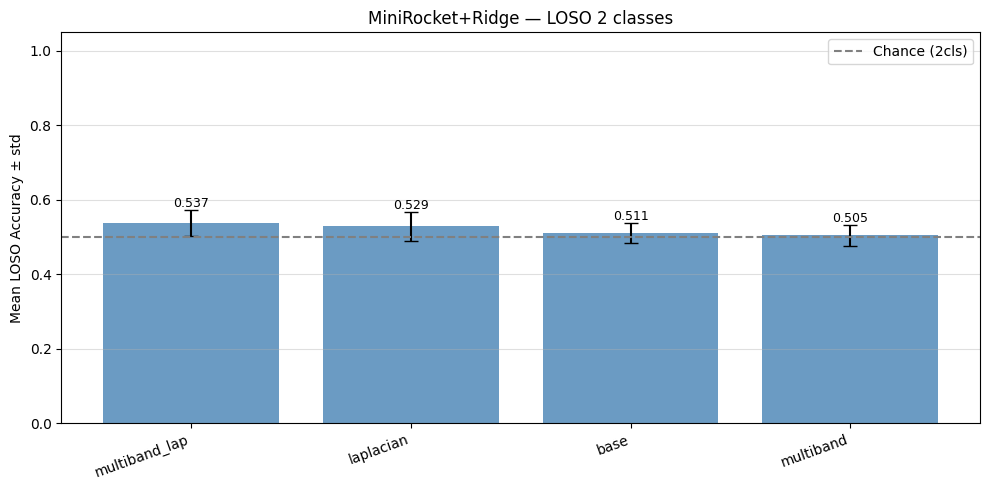

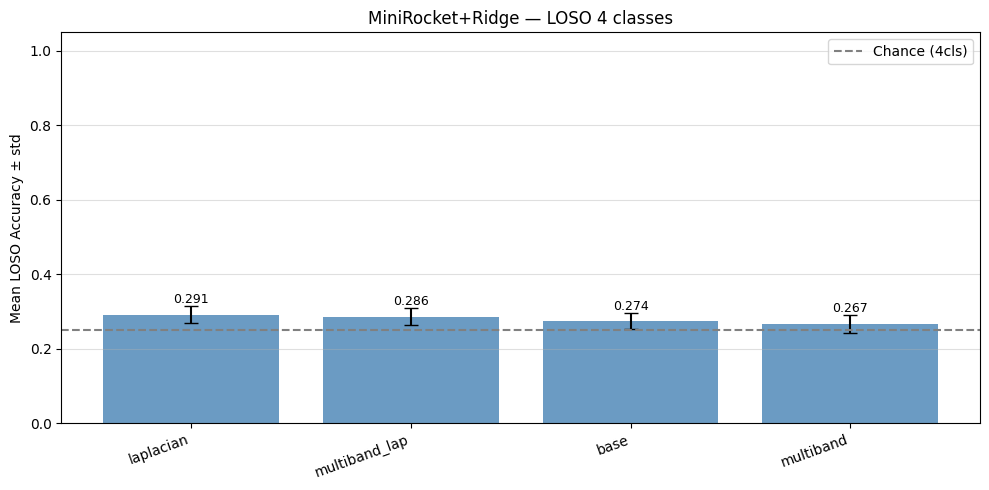

In [ ]:
meta_cols = ['config', 'classes', 'mean_acc', 'std_acc']
subj_cols = [c for c in df_loso_2.columns if c not in meta_cols]

for n_cls, df_src in [(2, df_loso_2), (4, df_loso_4)]:
    fig, ax = plt.subplots(figsize=(10, 5))
    configs  = df_src['config'].tolist()
    means    = df_src['mean_acc'].tolist()
    stds     = df_src['std_acc'].tolist()
    x = np.arange(len(configs))
    bars = ax.bar(x, means, yerr=stds, capsize=5,
                  color='steelblue', alpha=0.8)
    ax.bar_label(bars, fmt='%.3f', fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(configs, rotation=20, ha='right')
    ax.axhline(1/n_cls, color='gray', linestyle='--',
               label=f'Chance ({n_cls}cls)')
    ax.set_ylim(0.0, 1.05)
    ax.set_ylabel('Mean LOSO Accuracy ± std')
    ax.set_title(f'MiniRocket+Ridge — LOSO {n_cls} classes')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)
    plt.tight_layout()
    plt.savefig(f'../figures/MiniRocket_loso_{n_cls}cls.png',
                dpi=150, bbox_inches='tight')
    plt.show()

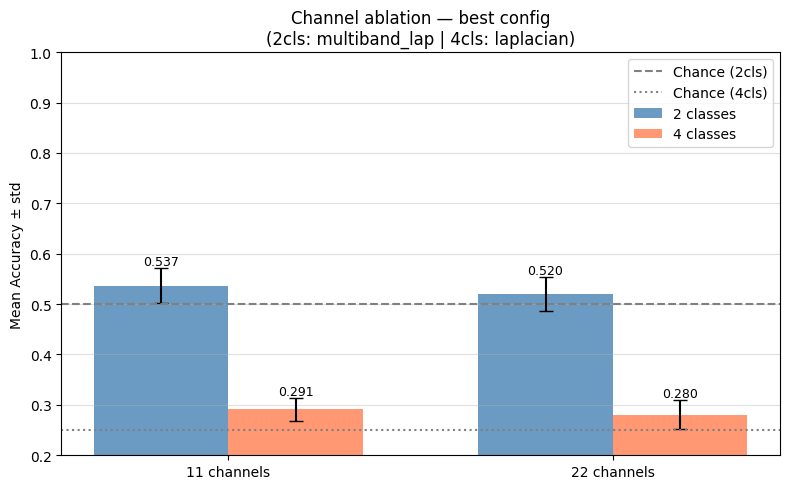

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

abl_2 = df_ch_ablation[df_ch_ablation['classes'] == 2].set_index('channels')
abl_4 = df_ch_ablation[df_ch_ablation['classes'] == 4].set_index('channels')

x = np.arange(2)
w = 0.35
b1 = ax.bar(x - w/2, abl_2.loc[['11ch', '22ch'], 'mean_acc'],
            w, yerr=abl_2.loc[['11ch', '22ch'], 'std_acc'],
            capsize=5, label='2 classes', color='steelblue', alpha=0.8)
b2 = ax.bar(x + w/2, abl_4.loc[['11ch', '22ch'], 'mean_acc'],
            w, yerr=abl_4.loc[['11ch', '22ch'], 'std_acc'],
            capsize=5, label='4 classes', color='coral', alpha=0.8)
ax.bar_label(b1, fmt='%.3f', fontsize=9)
ax.bar_label(b2, fmt='%.3f', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(['11 channels', '22 channels'])
ax.axhline(0.5,  color='gray', linestyle='--', label='Chance (2cls)')
ax.axhline(0.25, color='gray', linestyle=':',  label='Chance (4cls)')
ax.set_ylim(0.2, 1.0)
ax.set_ylabel('Mean Accuracy ± std')
ax.set_title(
    f'Channel ablation — best config\n'
    f'(2cls: {best_cfg_2["name"]} | 4cls: {best_cfg_4["name"]})'
)
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('../figures/MiniRocket_channel_ablation.png',
            dpi=150, bbox_inches='tight')
plt.show()